# <span style="color: yellow;">Master Notebook - ResNet50</span>

Since Greg wants a single notebook, we should organize everything into one organized, sequential notebook you can just run rom the start.  It'll have different sections for each compression algorithm and plot the results at the end on a Pareto front.

Please paste your functions applying your compression technique in the appropriate section.  The final deliverable is a <ins>Pareto Front</ins> graph, so what you need to output from your model is its <ins>% size reduction</ins> (how much you decreased parameters) and <ins>F1 accuracy</ins> at that size.

**Table of Contents:**
1. <ins>Data Preparation:</ins> this section pulls the necessary dataset from huggingface and instantiates a pytorch dataset/loaders
2. <ins>Pretrained Model Loading:</ins> this pulls our pretrained model (to which we will apply our compression & KD algorithms)
3. <ins>Basic Compression Algorithms:</ins> applies pruning, quantization, LTH, and RGP
4. <ins>Knowledge Distillation Algorithms:</ins> applied our NAS + KD algorithm and Pruning with KD algorithm
5. <ins>Final Comparison:</ins> illustrates the performance of our algorithms in a Pareto Front

In [1]:
# first we just ensure we are working in the right folder
import os
target_folder = "CS6423_knowledge_distillation_project" 
path = os.path.join(os.getcwd(), target_folder)

if not os.getcwd().endswith(target_folder):
    os.chdir(path)

print(f"Current working directory: {os.getcwd()}")

Current working directory: /home/kod6/CS6423_knowledge_distillation_project


## <span style="color: yellow;">1. Data Preparation</span>

In [2]:
# Fiachra - code that downloads the dataset and organizes the csv.

Here we prepare the dataset using Fiachra's modules:

In [3]:
# Fiachra - instantiate the dataset/dataloaders through the datasetPrepper
import pandas as pd
from modules.dataset_prepper import datasetPrepper

# sets path variables
pretrained_weights_path = "RadImageNet_weights/resnet50.pth"
dataframe_path = "data/labels.csv"
image_dir = "data/test_images"
model_name = "resnet50_baseline_cpu"

# loads dataset csv
dataframe = pd.read_csv(dataframe_path)
num_classes = dataframe["label"].nunique()

# prepare dataset with datasetPrepper module, print confirmations
data_prep = datasetPrepper(
    dataframe_path="data/labels.csv",
    image_dir="data/test_images",
).prepare(compute_class_weights=True)

print(f"Dataset prepared:")
print(f"  Train samples: {len(data_prep.train_dataset)}")
print(f"  Val samples: {len(data_prep.val_dataset)}")
print(f"  Test samples: {len(data_prep.test_dataset)}")
print(f"  Classes: {len(data_prep.class_names)}")

Dataset prepared:
  Train samples: 7948
  Val samples: 1590
  Test samples: 398
  Classes: 61


## <span style="color: yellow;">2. Pretrained Model Loading</span>
Section that loads the pretrained models - our baseline/teacher.  Requires your own huggingface read token for the model repo.

In [4]:
from huggingface_hub import snapshot_download, login
login("YOUR_HF_TOKEN_HERE")  # replace with your own HuggingFace token

snapshot_download(
    repo_id="fiabar/cs6423_model_repo",
    repo_type="model",
    local_dir=os.path.join(os.getcwd(), 'trained_models/')
)

Fetching 37 files:   0%|          | 0/37 [00:00<?, ?it/s]

'/home/kod6/CS6423_knowledge_distillation_project/trained_models'

Here we instantiate the pretrained ResNet50 and run an inference pass for the baseline.

In [5]:
import torch
from modules.imagenet_loader import ImagenetLoader
from modules.evaluate_model import ModelEvaluator

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# initialize loader class that will bring in our pretrained model
loader = ImagenetLoader()
resnet50 = loader.load_radimagenet_resnet50(
    "./trained_models/resnet50_baseline_gpu_new/resnet50_baseline_gpu_new.pth",
    load_type="load"
    )

# move teacher model to gpu
resnet50 = resnet50.to(device)
resnet50.eval()

# freeze teacher params, since we aren't doing any further training
for p in resnet50.parameters():
    p.requires_grad = False

# instantiate the model evaluator class with the test loader
evaluator = ModelEvaluator(data_loader=data_prep.test_loader, class_names=data_prep.class_names)

# evaluate our teacher
base_model_metrics = evaluator.evaluate_single(resnet50, "ResNet50 gpu new")
print(f"Our F1 score: {base_model_metrics['f1_macro']}\nOur total parameters: {base_model_metrics['total_parameters']}")


Warming up ResNet50 gpu new...
Running inference...
Our F1 score: 0.49377259670043605
Our total parameters: 23633021


/home/kod6/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## <span style="color: yellow;">3. Basic Compression Algorithms</span>

### Initializing our experiment tracker
Here we define a function that can append the results from each model compression algorithm to a dataframe for our Pareto Front visualization.  The tracker has:
* method: the method you used for compression (e.g., LTH, RGP, NAS+KD, etc.)
* base_model: the name of the model you are compressing (e.g., resnet10, resnet18, resnet50) 
* base_size: the number of parameters in the basic model
* compressed_size: the number of parameters in the model you compressed
* f1: the F1 score your compressed model has 

So, after you run each experiment, have something that looks like:

In [6]:
'''
Method = 'Pruning'
Base_Model = 'resnet10'
Base_Model_Parameters = 2012345
New_Model_Parameters = 2002345
F1_Score = 0.8
add_experiment(Method, Base_Model, Base_Model_Parameters, New_Model_Parameters, F1_Score)
'''

"\nMethod = 'Pruning'\nBase_Model = 'resnet10'\nBase_Model_Parameters = 2012345\nNew_Model_Parameters = 2002345\nF1_Score = 0.8\nadd_experiment(Method, Base_Model, Base_Model_Parameters, New_Model_Parameters, F1_Score)\n"

In [7]:
# initialize a dataframe we will append our results to
results_df = pd.DataFrame(columns=[
    'Method', 'Base_Model', 'Size_Reduction_Pct', 'F1_Score'
])

# function that can easily add results to the df
def add_experiment(method, base_model, base_size, compressed_size, f1):
    global results_df
    reduction = ((base_size - compressed_size) / base_size) * 100
    
    new_entry = {
        'Method': method,
        'Base_Model': base_model,
        'Size_Reduction_Pct': round(reduction, 2),
        'F1_Score': round(f1, 4),
    }
    
    results_df = pd.concat([results_df, pd.DataFrame([new_entry])], ignore_index=True)
    print(f"Logged: {method} | Reduction: {reduction:.1f}% | F1: {f1:.3f}")

# add out baseline model's metrics to the dataframe
add_experiment(method='N/A', 
               base_model='resnet50', 
               base_size=base_model_metrics['total_parameters'], 
               compressed_size=base_model_metrics['total_parameters'], 
               f1=base_model_metrics['f1_macro'])

Logged: N/A | Reduction: 0.0% | F1: 0.494


In [8]:
# Code or functions that apply basic pruning
from torch.nn.utils import prune
import copy

def random_prune(model, amount):
    # apply ranodm unstructured pruning
    for name, module in model.named_modules():
        if isinstance(module, (torch.nn.Linear, torch.nn.Conv2d)):
            prune.random_unstructured(module, name='weight', amount=amount)
            prune.remove(module, 'weight')
    #print(f'randomized unstructured pruning applied with amount: {amount}')

def magnitude_prune(model, amount):
    # apply random magnitude pruning
    for name, module in model.named_modules():
        if isinstance(module, (torch.nn.Linear, torch.nn.Conv2d)):
            prune.l1_unstructured(module, name='weight', amount=amount)
            prune.remove(module, 'weight')
    #print(f'magnitude pruning applied with amount: {amount}')


pruning_amounts = [0.1, 0.25, 0.5, 0.75, 0.9]
evaluator = ModelEvaluator(data_loader=data_prep.test_loader, class_names=data_prep.class_names, silent=True)

for amount in pruning_amounts:
    # initialize model copies
    model_random_pruned = copy.deepcopy(resnet50)
    model_magnitude_pruned = copy.deepcopy(resnet50)
    
    # apply prunings and record results
    random_prune(model_random_pruned, amount)
    metrics = evaluator.evaluate_single(model_random_pruned)
    #print(f'RANDOM PRUNE: Our F1 score: {metrics['f1_macro']}\n Our total parameters: {metrics['total_parameters']}')
    add_experiment(method='Random Pruning', 
                   base_model='resnet50',
                   base_size=base_model_metrics['total_parameters'], 
                   compressed_size=metrics['total_parameters'], 
                   f1=metrics['f1_macro'])
    
    magnitude_prune(model_magnitude_pruned, amount)
    metrics = evaluator.evaluate_single(model_magnitude_pruned)
    #print(f'RANDOM PRUNE: Our F1 score: {metrics['f1_macro']}\n Our total parameters: {metrics['total_parameters']}')
    add_experiment(method='Magnitude Pruning', 
                   base_model='resnet50', 
                   base_size=base_model_metrics['total_parameters'], 
                   compressed_size=metrics['total_parameters'], 
                   f1=metrics['f1_macro'])

display(results_df)

Logged: Random Pruning | Reduction: 10.0% | F1: 0.046


/home/kod6/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Logged: Magnitude Pruning | Reduction: 10.0% | F1: 0.497


/home/kod6/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Logged: Random Pruning | Reduction: 24.9% | F1: 0.000


...

/home/kod6/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Logged: Magnitude Pruning | Reduction: 74.8% | F1: 0.037


/home/kod6/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Logged: Random Pruning | Reduction: 89.8% | F1: 0.000
Logged: Magnitude Pruning | Reduction: 89.8% | F1: 0.003


,Method,Base_Model,Size_Reduction_Pct,F1_Score
0,N/A,resnet50,0.0,0.4938
1,Random Pruning,resnet50,9.98,0.0464
2,Magnitude Pruning,resnet50,9.98,0.4967
3,Random Pruning,resnet50,24.94,0.0004
4,Magnitude Pruning,resnet50,24.94,0.4947
5,Random Pruning,resnet50,49.89,0.0008
6,Magnitude Pruning,resnet50,49.89,0.4294
7,Random Pruning,resnet50,74.83,0.0
8,Magnitude Pruning,resnet50,74.83,0.0369
9,Random Pruning,resnet50,89.8,0.0002


### Basic Pruning and Quantization

In [9]:
# Code or functions that apply quantization

### Caylum - Lottery Ticket Hypothesis
Sentence or two to explain your method, then your code.

In [10]:
# Caylum - code or functions that apply LTH and output a few datapoints for the Pareto Front
# append to the dataframe as described above

### Kellie - RGP
Code/functions that apply RGP and output a few datapoints for the Pareto Front. RGP iteratively removes the least important convolution filters from ResNet50 using gradient-based importane scorea, sheinking the model in 5 steps from 10% to 50% sparsity. After each pruning step the model is fine-tunes to recover accuracy, trading off model size against F1 score acrpss 5 Pareto front points.

In [11]:
# Kellie - RGP: Rigorous Gradient-based Pruning
# Results loaded from pre-trained checkpoints saved by rgp.ipynb
# Models were trained with iterative structured pruning (DFOT scoring) across
# 5 sparsity levels (10%-50%), fine-tuned for 10 epochs each to recover accuracy.

import os
import torch
import pandas as pd

rgp_checkpoints = {
    '10%': 'trained_models/rgp_step_0.1/rgp_step_0.1_full.pth',
    '20%': 'trained_models/rgp_step_0.2/rgp_step_0.2_full.pth',
    '30%': 'trained_models/rgp_step_0.3/rgp_step_0.3_full.pth',
    '40%': 'trained_models/rgp_step_0.4/rgp_step_0.4_full.pth',
    '50%': 'trained_models/rgp_step_0.5/rgp_step_0.5_full.pth',
}

initial_params = sum(p.numel() for p in resnet50.parameters())
rgp_step_metrics = []

for sparsity, path in rgp_checkpoints.items():
    print(f"Loading RGP {sparsity} model from {path}...")

    rgp_model = torch.load(path, map_location=device, weights_only=False)['model']
    rgp_model = rgp_model.to(device)
    rgp_model.eval()

    step_metrics = evaluator.evaluate_single(rgp_model, f"RGP_{sparsity}")
    step_params  = sum(p.numel() for p in rgp_model.parameters())

    add_experiment(
        method='RGP',
        base_model='resnet50',
        base_size=initial_params,
        compressed_size=step_params,
        f1=step_metrics['f1_macro']
    )

    rgp_step_metrics.append({
        'Sparsity': sparsity,
        'Size Reduction (%)': round(((initial_params - step_params) / initial_params) * 100, 2),
        'F1 Score': round(step_metrics['f1_macro'], 4),
        'Size (MB)': round(step_metrics['model_size_mb'], 1),
        'Latency (ms)': round(step_metrics['avg_latency_ms'], 2),
    })

# Results summary table
summary_df = pd.DataFrame(rgp_step_metrics).set_index('Sparsity')
summary_df.index.name = 'RGP Step'
display(summary_df)

Loading RGP 10% model from trained_models/rgp_step_0.1/rgp_step_0.1_full.pth...
Logged: RGP | Reduction: 4.5% | F1: 0.305
Loading RGP 20% model from trained_models/rgp_step_0.2/rgp_step_0.2_full.pth...


/home/kod6/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Logged: RGP | Reduction: 7.2% | F1: 0.295
Loading RGP 30% model from trained_models/rgp_step_0.3/rgp_step_0.3_full.pth...


/home/kod6/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Logged: RGP | Reduction: 10.0% | F1: 0.285
Loading RGP 40% model from trained_models/rgp_step_0.4/rgp_step_0.4_full.pth...


...

Logged: RGP | Reduction: 12.6% | F1: 0.290
Loading RGP 50% model from trained_models/rgp_step_0.5/rgp_step_0.5_full.pth...


/home/kod6/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Logged: RGP | Reduction: 14.9% | F1: 0.301


/home/kod6/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Size Reduction (%),F1 Score,Size (MB),Latency (ms)
RGP Step,,,,
10%,4.53,0.3054,86.3,1.07
20%,7.16,0.2954,83.9,1.08
30%,10.01,0.2850,81.3,1.08
40%,12.64,0.2901,79.0,1.01
50%,14.94,0.3012,76.9,1.03


In [12]:
import subprocess
subprocess.run(["pip", "install", "seaborn"], check=True)

Defaulting to user installation because normal site-packages is not writeable


CompletedProcess(args=['pip', 'install', 'seaborn'], returncode=0)

## <span style="color: yellow;">4. Knowledge Distillation Algorithms</span>


### Ethan - NAS + KD Algorithm

In [13]:
# Ethan - code or functions that perform NAS + KD

### Ciara - PWKD
A few sentences to describe your method, then your code

In [14]:
# Ciara - code or functions that apply PWKD
# append results to the dataframe as described above

## <span style="color: yellow;">5. Final Comparison</span>
Illustrates the performance of our algorithms with a Pareto Front

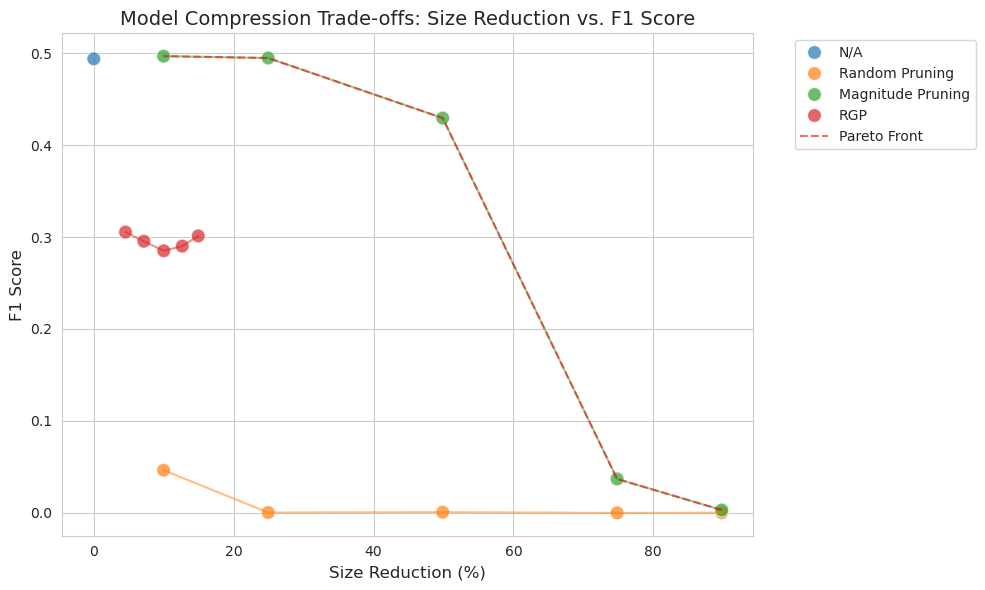

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_compression_pareto(df):
    # first we sort by size - want to find points where F1 is the highest for a given reduction level to determine pareto front
    df_sorted = df.sort_values(by='Size_Reduction_Pct')
    pareto_reduction = []
    pareto_f1 = []
    current_max_f1 = -1
    
    # iterate through them to find the best point
    # higher reduction AND higher/equal F1 than previous points
    for _, row in df_sorted.iloc[::-1].iterrows():
        if row['F1_Score'] >= current_max_f1:
            pareto_reduction.append(row['Size_Reduction_Pct'])
            pareto_f1.append(row['F1_Score'])
            current_max_f1 = row['F1_Score']

    # set up plot
    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")

    scatter = sns.scatterplot(  # plots all experiments
        data=df, 
        x='Size_Reduction_Pct', 
        y='F1_Score', 
        hue='Method', 
        s=100, 
        alpha=0.7
    )

    sns.lineplot(
        data=df,
        x='Size_Reduction_Pct',
        y='F1_Score',
        hue='Method',
        alpha=0.5,
        legend=False
    )
    
    # visualizes pareto frontier line
    plt.plot(pareto_reduction, pareto_f1, color='red', linestyle='--', alpha=0.6, label='Pareto Front')
    
    # add labels and whatnot
    plt.title('Model Compression Trade-offs: Size Reduction vs. F1 Score', fontsize=14)
    plt.xlabel('Size Reduction (%)', fontsize=12)
    plt.ylabel('F1 Score', fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    
    plt.show()
plot_compression_pareto(results_df)

In [16]:
# Use this for saving the results df to a csv file so we don't have to rerun everytime
results_df.to_csv("results.csv", mode='a', header=False, index=False)